## Use 3D decon for 2D images


Load the images and assign the wavelengths

In [ ]:
from skimage import imread
from tnia.plotting.plt_helper import imshow2d
import numpy as np

im_name = r"/home/bnorthan/images/tnia-python-images/imagesc/2026_03_30_2d_deconvolution_czi/CN500_4_13_11_25_001 (1).czi"

image = czifile.imread(im_name)
image = np.squeeze(image)

print(type(image), print(image.shape), print(image.dtype), print(image.min()), print(image.max()))

waves = ['DAPI', 'GFP', 'Cy3']
wavelengths = [0.360, 0.488, 0.550]  # excitation wavelengths in µm

print(image.shape)

from skimage.io import imsave
imsave('imagesc_puncti_gfp.tif', image[1,:,:])

(3, 1080, 1920)
uint8
5
255
<class 'numpy.ndarray'> None None None None
(3, 1080, 1920)


In [3]:
print(image.shape)
ind = np.s_[:,:,500:1200]
image = image[ind]
print(image.shape)

(3, 1080, 1920)
(3, 1080, 700)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


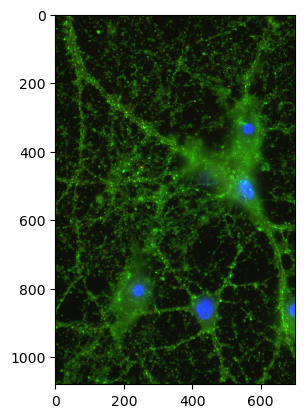

In [4]:
from tnia.plotting.plt_helper import color_dictionary, create_rgb, imshow_multi2d, create_linear_napari_color_map
import matplotlib.pyplot as plt

images = [image[0], image[1], image[2]]

color_image = create_rgb(images, waves, color_dictionary)

plt.imshow(color_image)

## Generate a PSF

DAPI (360 nm)  shape: (32, 64, 64)
GFP (488 nm)  shape: (32, 64, 64)
Cy3 (550 nm)  shape: (32, 64, 64)


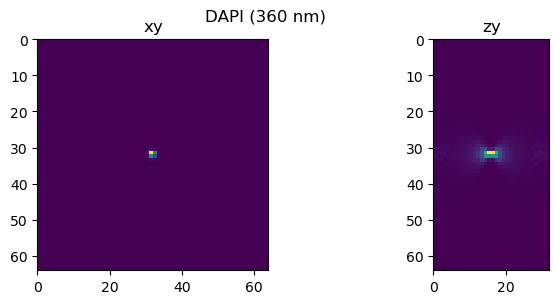

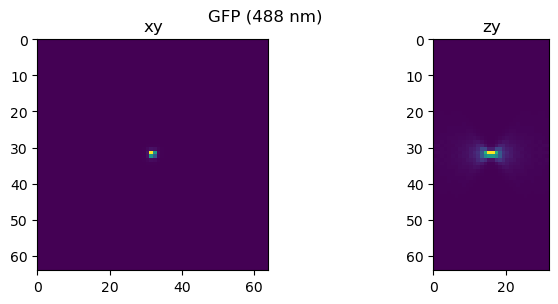

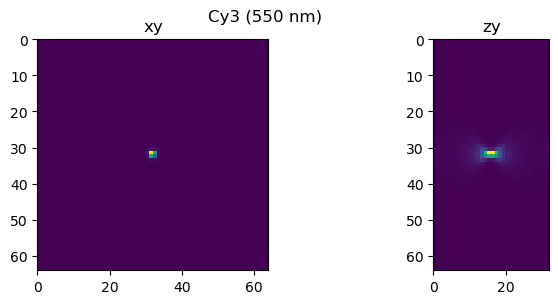

In [8]:
from tnia.deconvolution.psfs import gibson_lanni_3D
from tnia.plotting.projections import show_xy_zy_slice_center
import numpy as np
import matplotlib.pyplot as plt

xy_psf_dim = 64
NA = 1.4
x_voxel_size = 0.185
z_voxel_size = 0.185
z_psf_dim = 32
ni = 1.5
ns = 1.4
defocus = 0

psfs = []
for wave, wl in zip(waves, wavelengths):
    psf = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wl, use_psfm=True)
    psf = np.squeeze(psf.astype('float32'))
    psfs.append(psf)
    print(f'{wave} ({wl*1000:.0f} nm)  shape: {psf.shape}')

for psf, wave, wl in zip(psfs, waves, wavelengths):
    fig = show_xy_zy_slice_center(psf, sz=z_voxel_size/x_voxel_size, figsize=(8, 3))
    fig.suptitle(f'{wave} ({wl*1000:.0f} nm)', fontsize=12, y=0.98)
    fig.subplots_adjust(top=0.88)
    plt.show()

In [9]:
imsave('imagesc_psf_gfp.tif', psfs[1])

/tmp/ipykernel_54847/3349891128.py:1: UserWarning: imagesc_psf_gfp.tif is a low contrast image
  imsave('imagesc_psf_gfp.tif', psfs[1])


## Deconvolve the image using circulant and non-circulant 

Do decon twice because still fiddling with the API, and second time getting the 3D reconstruction back. 

In [29]:
# add trivial dimension to image
for i in range(len(images)):
    images[i] = images[i][None, ...]
    print(images[i].shape)

(1, 1080, 700)
(1, 1080, 700)
(1, 1080, 700)


In [30]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp
from tnia.deconvolution.decon_helper import create_saturation_mask

import timeit

num_iterations = 50

decons_circulant = []
decons_noncirculant = []

for noncirc in [False, True]:
    nc_label = 'noncirc' if noncirc else 'circular'
    for image, psf, wave in zip(images, psfs, waves):

        start = timeit.default_timer()    
        decon = richardson_lucy_cp(image, psf, num_iterations, noncirc=noncirc)
        total = timeit.default_timer() - start
        print(f'{wave} ({nc_label}): total time RL CP {total:.2f}s')

        if noncirc:
            decons_noncirculant.append(decon)
        else:
            decons_circulant.append(decon)


0 10 20 30 40 
DAPI (circular): total time RL CP 8.28s

0 10 20 30 40 
GFP (circular): total time RL CP 8.26s

0 10 20 30 40 
Cy3 (circular): total time RL CP 8.25s

0 10 20 30 40 
DAPI (noncirc): total time RL CP 6.98s

0 10 20 30 40 
GFP (noncirc): total time RL CP 6.98s

0 10 20 30 40 
Cy3 (noncirc): total time RL CP 6.99s


In [7]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp

import timeit

decons_circulant_3D = []
decons_noncirculant_3D = []
images_3D = []

for noncirc in [False, True]:
    nc_label = 'noncirc' if noncirc else 'circular'
    for image, psf, wave in zip(images, psfs, waves):

        start = timeit.default_timer()    
        decon, image = richardson_lucy_cp(image, psf, num_iterations, noncirc=noncirc, do_unpad=False)
        total = timeit.default_timer() - start
        print(f'{wave} ({nc_label}): total time RL CP {total:.2f}s')

        if noncirc:
            images_3D.append(image)
            decons_noncirculant_3D.append(decon)
        else:
            decons_circulant_3D.append(decon)


0 10 20 30 40 
DAPI (circular): total time RL CP 8.29s

0 10 20 30 40 
GFP (circular): total time RL CP 8.27s

0 10 20 30 40 
Cy3 (circular): total time RL CP 8.25s

0 10 20 30 40 
DAPI (noncirc): total time RL CP 6.98s

0 10 20 30 40 
GFP (noncirc): total time RL CP 7.00s

0 10 20 30 40 
Cy3 (noncirc): total time RL CP 6.99s


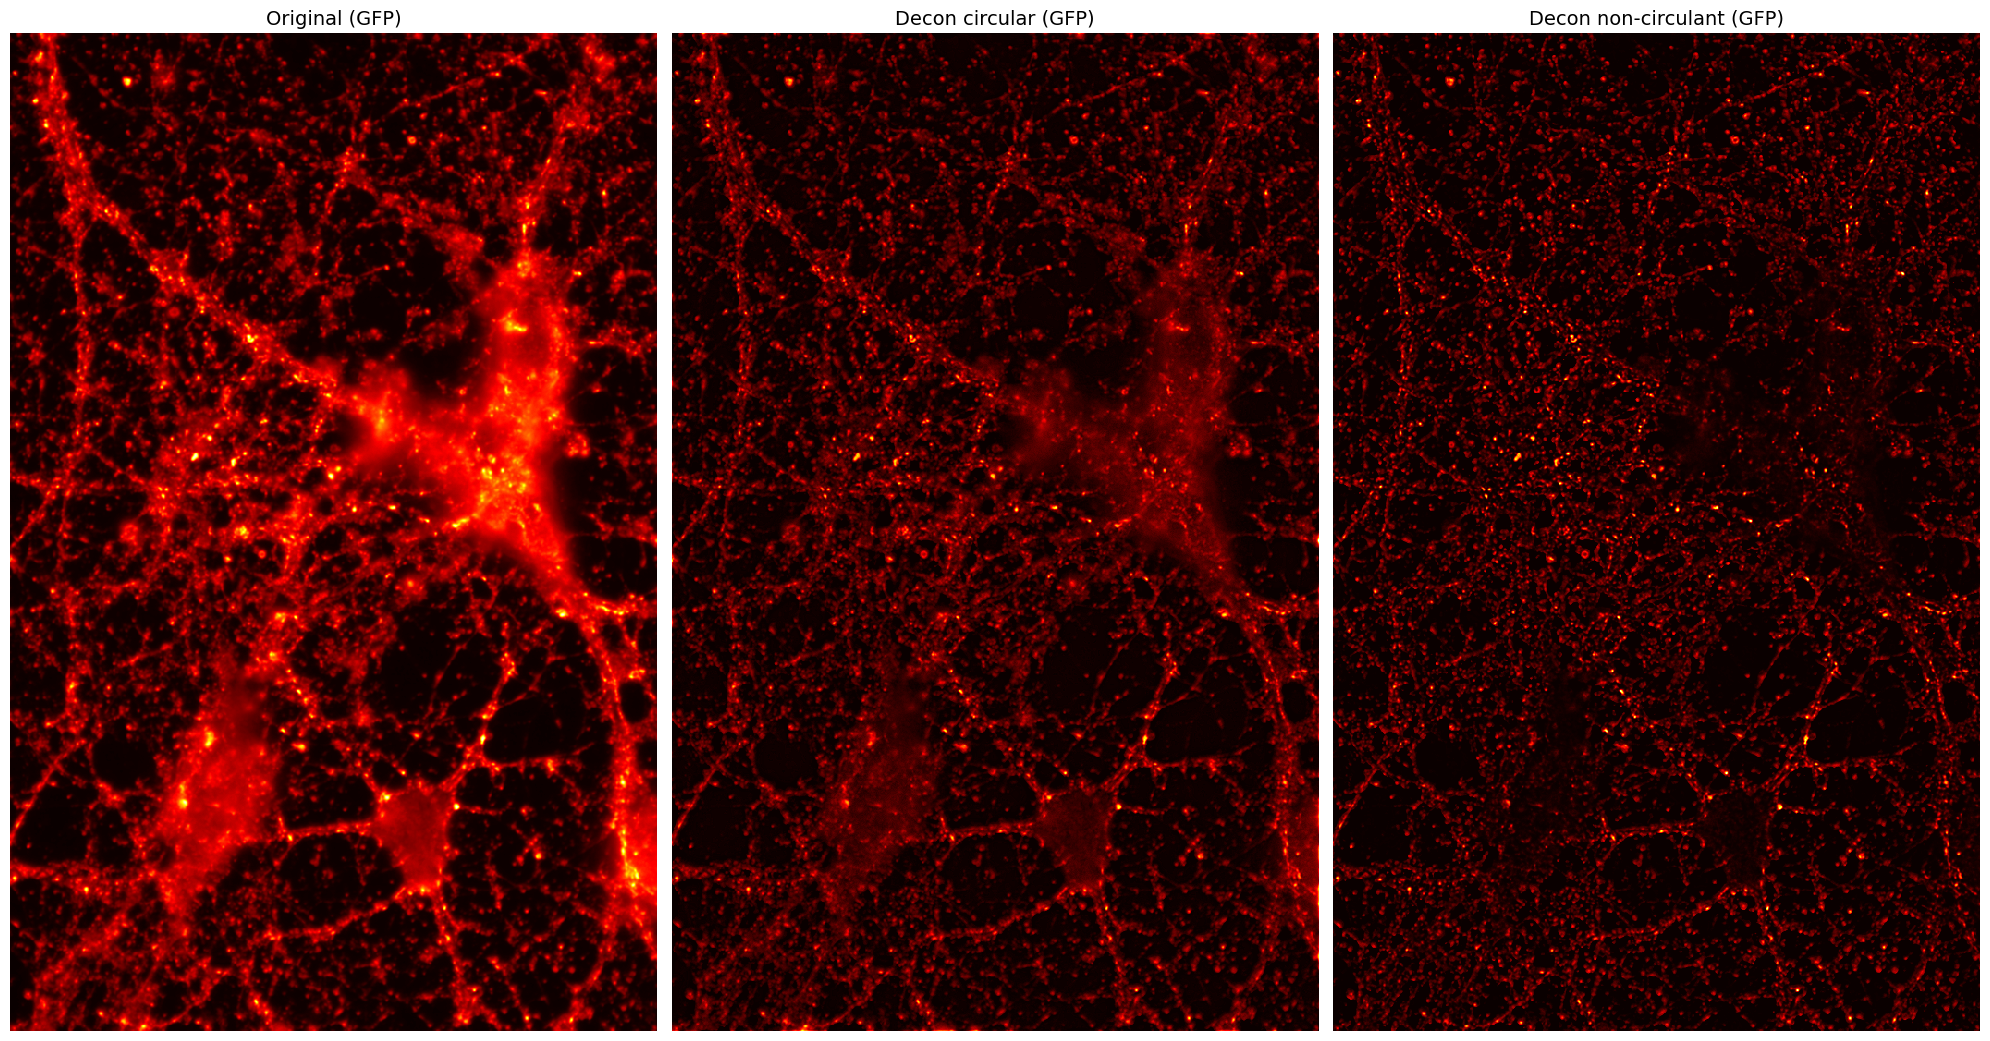

In [8]:
import matplotlib.pyplot as plt

cmap = 'hot'

im_gfp = images[1].squeeze()
decon_circ_gfp = decons_circulant[1].squeeze()
decon_nc_gfp = decons_noncirculant[1].squeeze()

fig, axes = plt.subplots(1, 3, figsize=(20, 12))
for ax, img, title in zip(axes,
                           [im_gfp, decon_circ_gfp, decon_nc_gfp],
                           ['Original (GFP)', 'Decon circular (GFP)', 'Decon non-circulant (GFP)']):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

Take a look at 3d slice projections (even though we are deconvolving a 3D image, we are reconstructing in a 3d space)

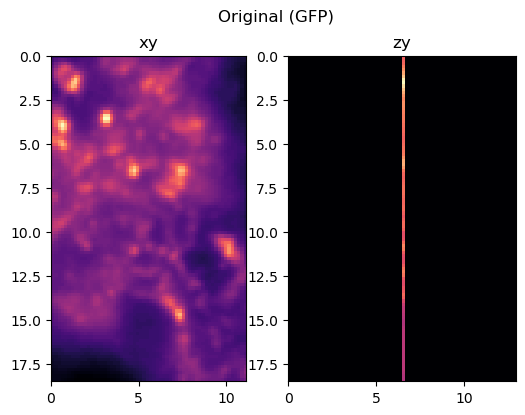

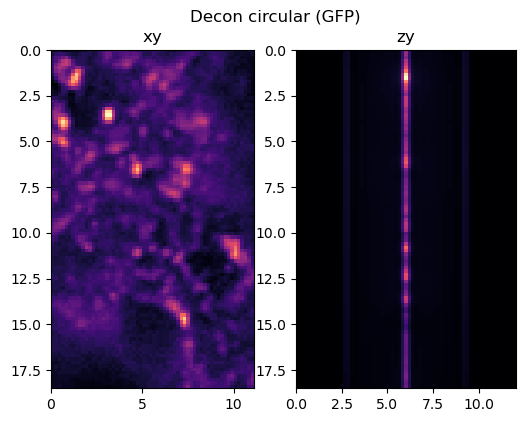

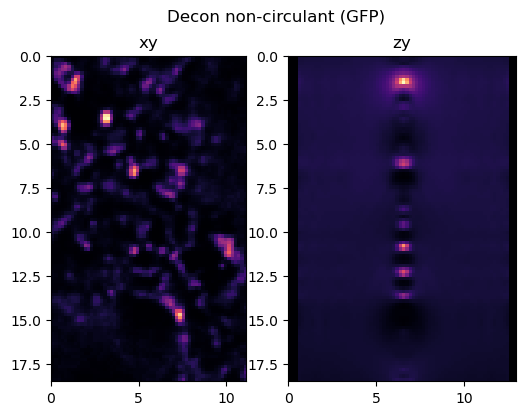

In [9]:
from tnia.plotting.projections import show_xy_zy_slice

size_x = 60
size_y = 100
start_x = 580
start_y = 540
ind = np.s_[:,start_y-size_y//2:start_y+size_y//2,start_x-size_x//2:start_x+size_x//2]

dif_x = (images_3D[0].shape[2]-decons_circulant_3D[1].shape[2])//2
dif_y = (images_3D[0].shape[1]-decons_circulant_3D[1].shape[1])//2
ind_circulant = np.s_[:,start_y-size_y//2-dif_y:start_y+size_y//2-dif_y,start_x-size_x//2-dif_x:start_x+size_x//2-dif_x]

images_3D_temp = images_3D[1].get()[ind]
decons_circulant_3D_temp = decons_circulant_3D[1][ind_circulant]
decons_noncirculant_3D_temp = decons_noncirculant_3D[1][ind]

for vol, title in zip([images_3D_temp, decons_circulant_3D_temp, decons_noncirculant_3D_temp],
                       ['Original (GFP)', 'Decon circular (GFP)', 'Decon non-circulant (GFP)']):
    fig = show_xy_zy_slice(vol, vol.shape[2]//2, vol.shape[1]//2, vol.shape[0]//2, sxy=x_voxel_size, sz=z_voxel_size, figsize=(6, 4.5), colormap='magma', show_cross_hairs=False)
    fig.suptitle(title, fontsize=12, y=0.98)
    fig.subplots_adjust(top=0.92)
    plt.show()

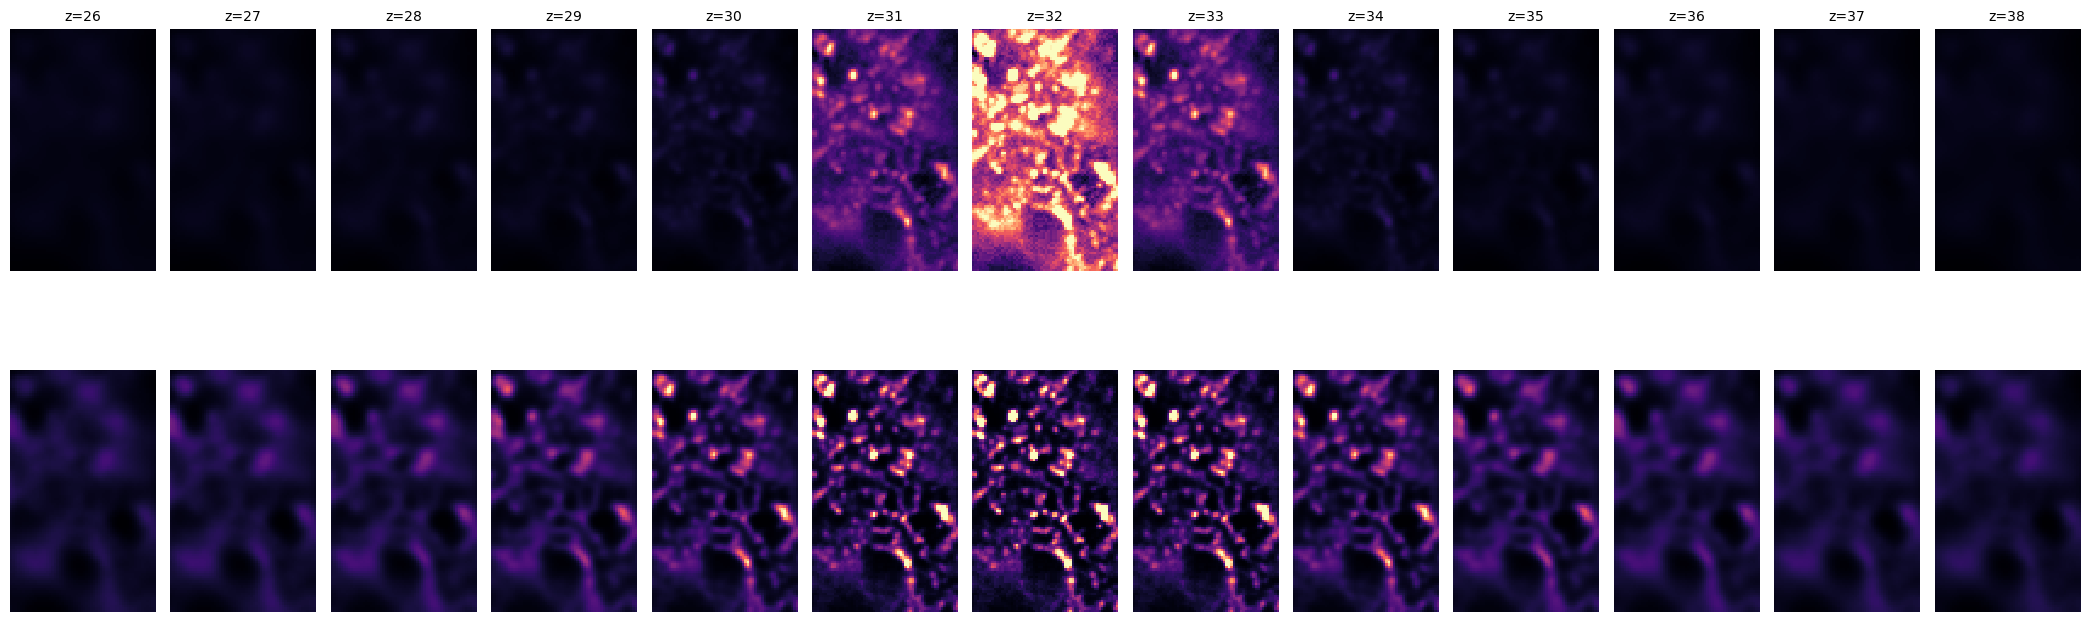

In [19]:
vols = [decons_circulant_3D_temp, decons_noncirculant_3D_temp]
row_titles = ['Original (GFP)', 'Decon circular (GFP)', 'Decon non-circulant (GFP)']

fig, axes = plt.subplots(2, 13, figsize=(21, 8))

for row, (vol, rtitle) in enumerate(zip(vols, row_titles)):
    zc = vol.shape[0] // 2
    max = vol.max()
    slices = range(zc - 6, zc + 7)
    for col, z in enumerate(slices):
        axes[row, col].imshow(vol[z], cmap='magma', vmax=max/3)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'z={z}', fontsize=10)
    axes[row, 0].set_ylabel(rtitle, fontsize=11, rotation=90, labelpad=10)
    axes[row, 0].yaxis.set_visible(True)
    axes[row, 0].tick_params(left=False, labelleft=False)

plt.tight_layout()
plt.show()

In [24]:
import napari
zc = decons_noncirculant_3D[1].shape[0] // 2
viewer = napari.Viewer()
viewer.add_image(decons_noncirculant_3D[1], name='Decon non-circulant (GFP)', scale = [10,1,1])

<Image layer 'Decon non-circulant (GFP)' at 0x7fbab42dcca0>